In [27]:
from pathlib import Path
import pandas as pd

path = Path("misure_interessanti") / "submatrix" / "export_matrix_scan_251110_163602_cap50_submatrix.tsv"

if not path.exists():
    raise FileNotFoundError(f"File non trovato: {path.resolve()}")

df = pd.read_csv(path, sep="\t", encoding="utf-8", engine="python")
df.head()

,col,row,voltage,tot_avg,tot_std,toa_avg,toa_std,efficiency_tot,efficiency_toa
0,3,3,100,5.000,0.000,11.613,0.495,1.0,1.0
1,3,3,97,5.000,0.000,11.742,0.445,1.0,1.0
2,3,3,94,5.000,0.000,11.935,0.250,1.0,1.0
3,3,3,91,4.935,0.250,12.000,0.000,1.0,1.0
4,3,3,88,4.645,0.486,12.000,0.000,1.0,1.0


In [28]:
import numpy as np
from scipy.special import erf
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt

# erf S-curve model
def myERF(x, mu, sigma):
    x = np.asarray(x)
    return 0.5 * (1.0 + erf((x - mu) / (sigma * np.sqrt(2.0))))

#cols = ["efficiency_tot", "efficiency_toa"]
cols = ["efficiency_toa"]
results = []

# group by pixel (row, col)
for (r, c), group in df.groupby(["row", "col"]):
    x_min, x_max = group["voltage"].min(), group["voltage"].max()
    for col in cols:
        if col not in group.columns:
            continue
        valid = group[["voltage", col]].dropna()
        npts = len(valid)
        if npts < 4:
            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts, "threshold": np.nan, "dispersion": np.nan, "success": False}
            )
            continue

        xdata = valid["voltage"].values
        ydata = valid[col].values

        guess = [np.median(xdata), max(1.0, (xdata.max() - xdata.min()) / 4.0)]
        try:
            popt, pcov = curve_fit(
                myERF,
                xdata,
                ydata,
                p0=guess,
                bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
                maxfev=5000,
            )
            fit_mu, fit_sigma = float(popt[0]), float(popt[1])
            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts, "threshold": fit_mu, "dispersion": fit_sigma, "success": True}
            )
        except Exception:
            results.append(
                {"row": r, "col": c, "metric": col, "n_points": npts, "threshold": np.nan, "dispersion": np.nan, "success": False}
            )

# results dataframe
fit_df = pd.DataFrame(results)
fit_out_path = path.parent / "fit_results_per_pixel.csv"
fit_df.to_csv(fit_out_path, index=False)
print(f"Saved {len(fit_df)} fit records to: {fit_out_path}")



Saved 40 fit records to: misure_interessanti\submatrix\fit_results_per_pixel.csv


Soglia media: 47.42 ± 0.55


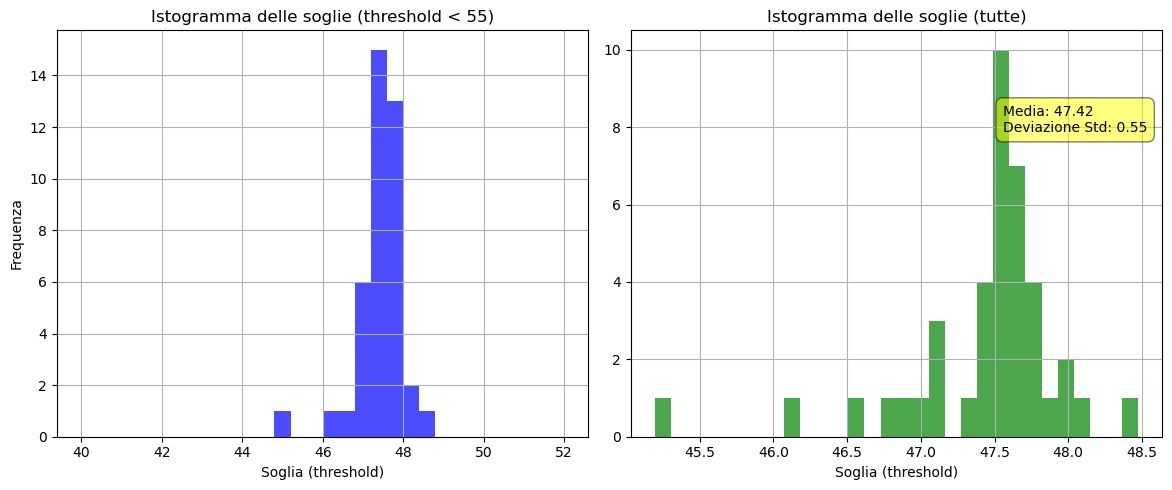

In [33]:
# Visualizza gli elementi della colonna 'threshold' del dataframe fit_df

thr_lt350 = fit_df.loc[fit_df["threshold"] < 200, "threshold"]
#soglie minori di 200 e maggiori di 50

#thr_lt350 = fit_df.loc[(fit_df["threshold"] < 200) & (fit_df["threshold"] > 52), "threshold"] 

# calcola media e deviazione standard delle soglie
mean_threshold = thr_lt350.mean()
std_threshold = thr_lt350.std()
print(f"Soglia media: {mean_threshold:.2f} ± {std_threshold:.2f}")


# affianca i due istogrammi (side-by-side)
fig_hist, axs_hist = plt.subplots(1, 2, figsize=(12, 5))

axs_hist[0].hist(thr_lt350.dropna(), bins=30, color='blue', alpha=0.7, range=(40, 52))
axs_hist[0].set_title("Istogramma delle soglie (threshold < 55)")
axs_hist[0].set_xlabel("Soglia (threshold)")
axs_hist[0].set_ylabel("Frequenza")
axs_hist[0].grid(True)

axs_hist[1].hist(fit_df["threshold"].dropna(), bins=30, color='green', alpha=0.7)
axs_hist[1].set_title("Istogramma delle soglie (tutte)")
axs_hist[1].set_xlabel("Soglia (threshold)")
axs_hist[1].grid(True)

# annotazione con media e deviazione standard
axs_hist[1].annotate(f"Media: {mean_threshold:.2f}\nDeviazione Std: {std_threshold:.2f}",
                     xy=(0.70, 0.75), xycoords='axes fraction',
                     bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.5))

plt.tight_layout()
plt.show()




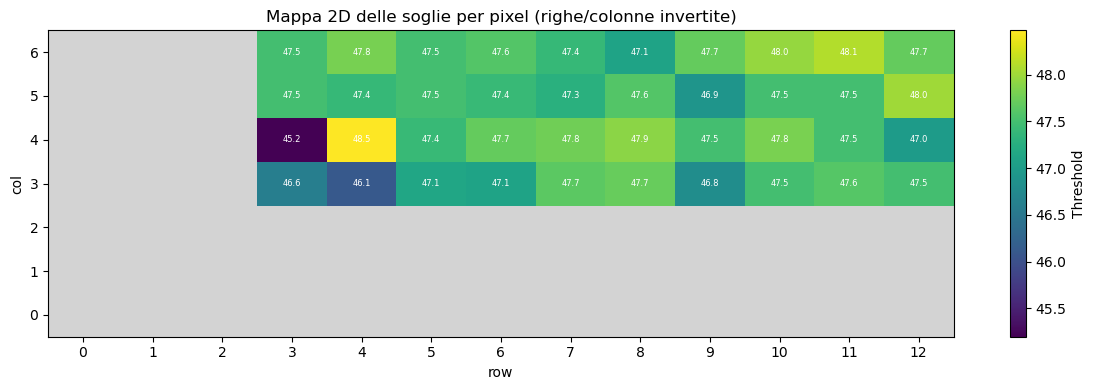

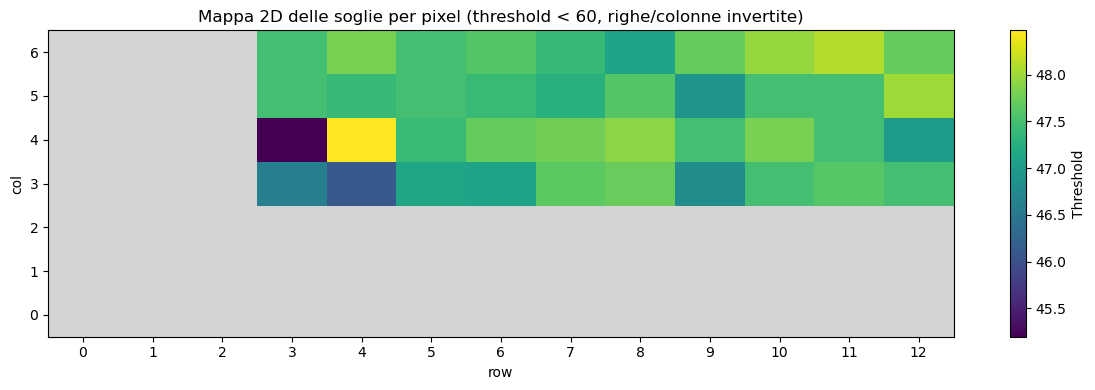

In [32]:
# righe e colonne scambiate: costruisco la mappa con shape (n_col, n_row)


n_row = int(fit_df["row"].max()) + 1
n_col = int(fit_df["col"].max()) + 1
thr_map = np.full((n_col, n_row), np.nan)  # note: rows=col, cols=row

for _, r in fit_df.iterrows():
    # pos: (original col, original row)
    thr_map[int(r["col"]), int(r["row"])] = r["threshold"] if r.get("success", True) else np.nan

masked = np.ma.masked_invalid(thr_map)
cmap = cmap if 'cmap' in globals() else plt.cm.viridis.copy()
try:
    cmap = cmap.copy()
    cmap.set_bad(color="lightgray")
except Exception:
    pass

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(masked, origin="lower", cmap=cmap, interpolation="nearest", aspect="auto")

# ora asse X = row (original), asse Y = col (original)
ax.set_xlabel("row")
ax.set_ylabel("col")
ax.set_xticks(np.arange(n_row))
ax.set_yticks(np.arange(n_col))

# etichette più sparse se troppe
if n_row > 32:
    ax.set_xticks(np.arange(0, n_row, max(1, n_row // 16)))
if n_col > 16:
    ax.set_yticks(np.arange(0, n_col, max(1, n_col // 8)))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Threshold")

# annota valori (attento: molti pixel -> disabilitare)
for i in range(n_col):       # i corrisponde all'originale col
    for j in range(n_row):   # j corrisponde all'originale row
        v = thr_map[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=6, color="white")

ax.set_title("Mappa 2D delle soglie per pixel (righe/colonne invertite)")
plt.tight_layout()
plt.show()

# versione filtrata (threshold < 60)
masked_filtered = np.ma.masked_invalid(np.where(thr_map < 60, thr_map, np.nan))
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(masked_filtered, origin="lower", cmap=cmap, interpolation="nearest", aspect="auto")

ax.set_xlabel("row")
ax.set_ylabel("col")
ax.set_xticks(np.arange(n_row))
ax.set_yticks(np.arange(n_col))
if n_row > 32:
    ax.set_xticks(np.arange(0, n_row, max(1, n_row // 16)))
if n_col > 16:
    ax.set_yticks(np.arange(0, n_col, max(1, n_col // 8)))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Threshold")
ax.set_title("Mappa 2D delle soglie per pixel (threshold < 60, righe/colonne invertite)")
plt.tight_layout()
plt.show()


Dispersion < 14: mean = 1.30, std = 0.29


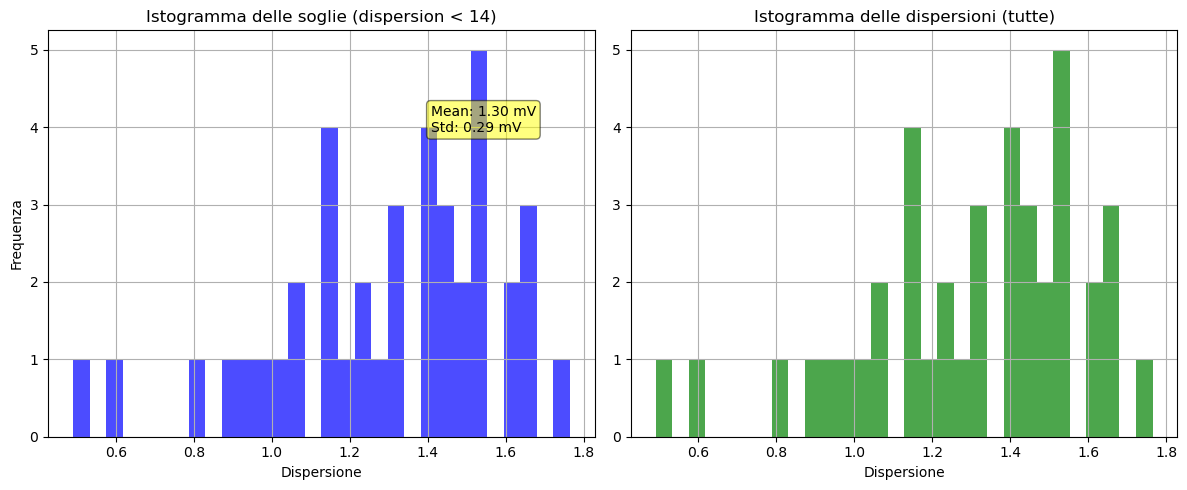

In [34]:
# Visualizza gli elementi della colonna 'threshold' del dataframe fit_df

#for v in fit_df["dispersion"]:
#    print(v)
thr_lt14 = fit_df.loc[fit_df["dispersion"] < 14, "dispersion"]





# calcola media e deviazione standard della distribuzione di thr_lt14 se fit gaussiana
mean_dispersion = thr_lt14.mean()
std_dispersion = thr_lt14.std()

print(f"Dispersion < 14: mean = {mean_dispersion:.2f}, std = {std_dispersion:.2f}")


# affianca i due istogrammi (side-by-side)
fig_hist, axs_hist = plt.subplots(1, 2, figsize=(12, 5))

axs_hist[0].hist(thr_lt14.dropna(), bins=30, color='blue', alpha=0.7)
    
axs_hist[0].set_title("Istogramma delle soglie (dispersion < 14)")
axs_hist[0].set_xlabel("Dispersione")
axs_hist[0].set_ylabel("Frequenza")
axs_hist[0].grid(True)



axs_hist[1].hist(fit_df["dispersion"].dropna(), bins=30, color='green', alpha=0.7)
axs_hist[1].set_title("Istogramma delle dispersioni (tutte)")
axs_hist[1].set_xlabel("Dispersione")
axs_hist[1].grid(True)

# annotazione con media e deviazione standard
axs_hist[0].annotate(f"Mean: {mean_dispersion:.2f} mV\nStd: {std_dispersion:.2f} mV",
                     xy=(0.70, 0.75), xycoords='axes fraction',
                     bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

plt.tight_layout()
plt.show()
